2D system of ReLU units. Dynamics are:

\begin{equation}
    \dot{x}(t) = W\left[ x \right]^+ - x + u
\end{equation}

\begin{equation}
W = \begin{pmatrix}
w_{11} - w_1^{\rm inh} & w_{12} - w_1^{\rm inh}\\
w_{21} - w_2^{\rm inh} & w_{22} - w_2^{\rm inh}
\end{pmatrix}
\end{equation}

Each entry in W evolves as:

\begin{equation} 
    \dot{w}_{ij}(t) = - x_i(t) \tilde{x}_j(t) + \tilde{x}_i(t) x_j(t) + \epsilon - \sum_k w_{kj}
\end{equation}

where the $\sim$ denotes a convolutions with an exponentially decaying filter:

\begin{equation}
    \tilde{x}(t) = \int_0^t e^{-(t - s)/\tau} x(s) \, ds
\end{equation}

For small $\tau$, we can define $v = t - s$. Substituting $s = t - v$ and $dv = -ds$ and changing the integration bounds, we have:

\begin{equation}
    \tilde{x}(t) = \int_t^0 e^{-v/\tau} x(t-v) \, (-dv) = \int_0^t e^{-v/\tau} x(t-v) \, dv
\end{equation}

$x(t-v)$ will only contribute if $v$ is small relative to $tau$, thus we can substitute:

\begin{equation}
    x(t-v) = x(t) - v x'(t) \; + \; ...
\end{equation}

This yields:

\begin{equation}
    \tilde{x}(t) = \int_0^t e^{-v/\tau} \left(x(t) - v x'(t)\right)  \, dv
\end{equation}

Assuming $\tau << t$, we can use the  identity:

\begin{equation}
    \int_0^{\infty} v^n e^{-v/\tau} = n! \; \tau^{n+1}
\end{equation}

Thus,

\begin{equation}
    \tilde{x}(t) = \tau x(t) - \tau^2 \dot{x}(t)
\end{equation}

The equation governing $W$ then becomes:

\begin{equation}
    \dot{w}_{ij}(t) = \left(\tau x_i(t) - \tau^2 \dot{x}_i(t)\right) x_j(t) - x_i(t) \left(\tau x_j(t) - \tau^2 \dot{x}_j(t)\right) + \epsilon - \sum_k w_{kj}
\end{equation}

\begin{equation}
    \dot{w}_{ij}(t) = \tau^2 \left[x_i(t) \dot{x}_j(t) - \dot{x}_i(t) x_j(t)\right] + \epsilon - \sum_k w_{kj}
\end{equation}

We can now search for fixed points of the system by setting all fixed points to zero:


    

The first equation can be rewritten as

\begin{equation}
    0 = (x_2 - x_1) (1 - (x_1 + x_2))
\end{equation}

yielding that either $x_1 = x_2$ or $x_2 = 1 - x_1$.

Substituting the latter into the second equation yields:

\begin{equation}
    0 = (w_{11} - 1) x_1 + w_{21} (1 - x_1) + u_1
\end{equation}

Regrouping terms

\begin{equation}
    0 = (w_{11} - 1 - w_{21}) x_1 + w_{21} + u_1
\end{equation}

This equation can be satisfied for arbitrary $x_1$ if

\begin{equation}
    w_{11} - 1 - w_{21} = 0
\end{equation}

\begin{equation}
    w_{21} + u_1 = 0
\end{equation}

Similarly, subsituting $x_2 = 1 - x_1$ into the last equation yields:

\begin{equation}
    0 = w_{12} x_1 + (w_{22} - 1) (1 - x_1) + u_2
\end{equation}

\begin{equation}
    0 = (w_{12} - w_{22} + 1) x_1 + w_{22} - 1 + u_2
\end{equation}

This can be true for arbitray $x_1$ if:

\begin{equation}
    0 = w_{12} - w_{22} + 1
\end{equation}

\begin{equation}
    0 = w_{22} - 1 + u_2
\end{equation}

In summary, we have found a line of fixed points corresponding to

\begin{equation}
    x_{2} = 1 - x_1
\end{equation}

\begin{equation}
    w_{12} = -u_2
\end{equation}

\begin{equation}
    w_{21} = -u_1
\end{equation}

for arbitrary $x_1$ under the conditions that:

\begin{equation}
    w_{22} = 1 - u_2
\end{equation}

\begin{equation}
    w_{11} = 1 - u_1
\end{equation}

Note, $w_{11}$ and $w_{22}$ do not evolve under the synaptic update rule since setting $i = j$ leads the update to be zero.




To determine the stability of the fixed point, we must linearize the dynamics about a point of this fixed line.

The total dynamics of the system are given by:

\begin{equation}
    \dot{x}(t) = W\left[ x \right]^+ - x + u
\end{equation}

\begin{equation}
    \dot{w}_{ij}(t) = \tau^2 \left[\dot{x}_i(t) x_j(t) - x_i(t) \dot{x}_j(t)\right]- x_i (1 - x_i) + x_j (1 - x_j) 
\end{equation}

We can substitute the first equation into the second to get:

\begin{equation}
    \dot{w}_{ij}(t) = \tau^2 \left[((w_{ii}-1) x_i + w_{ji} x_j + u_i) x_j(t) - x_i(t) ((w_{jj}-1) x_j + w_{ij} x_i + u_j)\right]- x_i (1 - x_i) + x_j (1 - x_j) 
\end{equation}

We can now compute the Jacobian of this system about the fixed line described. We define:

\begin{equation}
    \theta = \begin{pmatrix}
    x_1 \\
    x_2 \\
    w_{21} \\
    w_{12} \\
    \end{pmatrix}
\end{equation}

We would like to compute:

\begin{equation}
    \frac{d}{d \theta} \dot{\theta} |_{\theta^*(x_1^*)} = \frac{d}{d \theta}  F(\theta) |_{\theta^*(x_1^*)}
\end{equation}

where

\begin{equation}
    \theta^*(x_1^*) = \begin{pmatrix}
    x_1^* \\
    1 - x_1^* \\
    -u_1 \\
    -u_2 \\
    \end{pmatrix}
\end{equation}

The full Jacobian is given by:

\begin{equation}
J =
\begin{bmatrix}
\frac{\partial \dot{x_i}}{\partial x_i} & \frac{\partial \dot{x_i}}{\partial x_j} & \frac{\partial \dot{x_i}}{\partial w_{ji}} & \frac{\partial \dot{x_i}}{\partial w_{ij}} \\
\frac{\partial \dot{x_j}}{\partial x_i} & \frac{\partial \dot{x_j}}{\partial x_j} & \frac{\partial \dot{x_j}}{\partial w_{ji}} & \frac{\partial \dot{x_j}}{\partial w_{ij}} \\
\frac{\partial \dot{w}_{ji}}{\partial x_i} & \frac{\partial \dot{w}_{ji}}{\partial x_j} & \frac{\partial \dot{w}_{ji}}{\partial w_{ji}} & \frac{\partial \dot{w}_{ji}}{\partial w_{ij}} \\
\frac{\partial \dot{w}_{ij}}{\partial x_i} & \frac{\partial \dot{w}_{ij}}{\partial x_j} & \frac{\partial \dot{w}_{ij}}{\partial w_{ji}} & \frac{\partial \dot{w}_{ij}}{\partial w_{ij}}
\end{bmatrix}
\end{equation}

About the fixed point, this is

\begin{equation}
J\Big|_{\theta^*} =
\begin{bmatrix}
-u_i & -u_i & 1 - x_i^* & 0 \\[6pt]
-u_j & -u_j & 0 & x_i^* \\[6pt]
\tau^{2}\!\bigl(u_i - x_i^*(u_i+u_j)\bigr) + 1 - 2x_i^* &
\tau^{2}\!\bigl(u_i - x_i^*(u_i+u_j)\bigr) + 1 - 2x_i^* &
-\tau^{2}\,(1 - x_i^*)^{2} & \tau^{2}\,(x_i^*)^{2} \\[6pt]
-\tau^{2}\!\bigl(u_i - x_i^*(u_i+u_j)\bigr) - 1 + 2x_i^* &
-\tau^{2}\!\bigl(u_i - x_i^*(u_i+u_j)\bigr) - 1 + 2x_i^* &
\tau^{2}\,(1 - x_i^*)^{2} & -\,\tau^{2}\,(x_i^*)^{2}
\end{bmatrix}
\end{equation}

In [1]:
%load_ext autoreload
%autoreload 2

import sympy as sp

# Define symbols
x1, u1, u2, tau = sp.symbols('x1 u1 u2 tau', real=True)

# Define the Jacobian matrix
J = sp.Matrix([
    [-u1, -u1, 1 - x1, 0],
    [-u2, -u2, 0, x1],
    [tau**2 * (u1 - x1 * (u1 + u2)) + 1 - 2*x1,
     tau**2 * (u1 - x1 * (u1 + u2)) + 1 - 2*x1,
     -tau**2 * (1 - x1)**2,
     tau**2 * x1**2],
    [-tau**2 * (u1 - x1 * (u1 + u2)) - 1 + 2*x1,
     -tau**2 * (u1 - x1 * (u1 + u2)) - 1 + 2*x1,
     tau**2 * (1 - x1)**2,
     -tau**2 * x1**2]
])

# Compute eigenvalues
eigenvals = J.eigenvals()

# Compute eigenvectors
eigenvects = J.eigenvects()

print(len(eigenvects))

for eig in eigenvects:
    val, mult, vects = eig
    print(f"\nEigenvalue: {sp.simplify(val)}")
    print("Eigenvectors:")
    for v in vects:
        print(f"  {sp.simplify(v)}")


KeyboardInterrupt



$$
\lambda_{\pm} = -\tau^2 x_1^2 + \tau^2 x_1 - \frac{\tau^2}{2} - \frac{u_1}{2} - \frac{u_2}{2} \;\pm\; \frac{1}{2} \sqrt{ 4 \tau^4 x_1^4 - 8 \tau^4 x_1^3 + 8 \tau^4 x_1^2 - 4 \tau^4 x_1 + \tau^4 + 4 \tau^2 u_1 x_1^2 - 8 \tau^2 u_1 x_1 + 2 \tau^2 u_1 + 4 \tau^2 u_2 x_1^2 - 2 \tau^2 u_2 + u_1^2 + 2 u_1 u_2 + u_2^2 + 16 x_1^2 - 16 x_1 + 4 }
$$

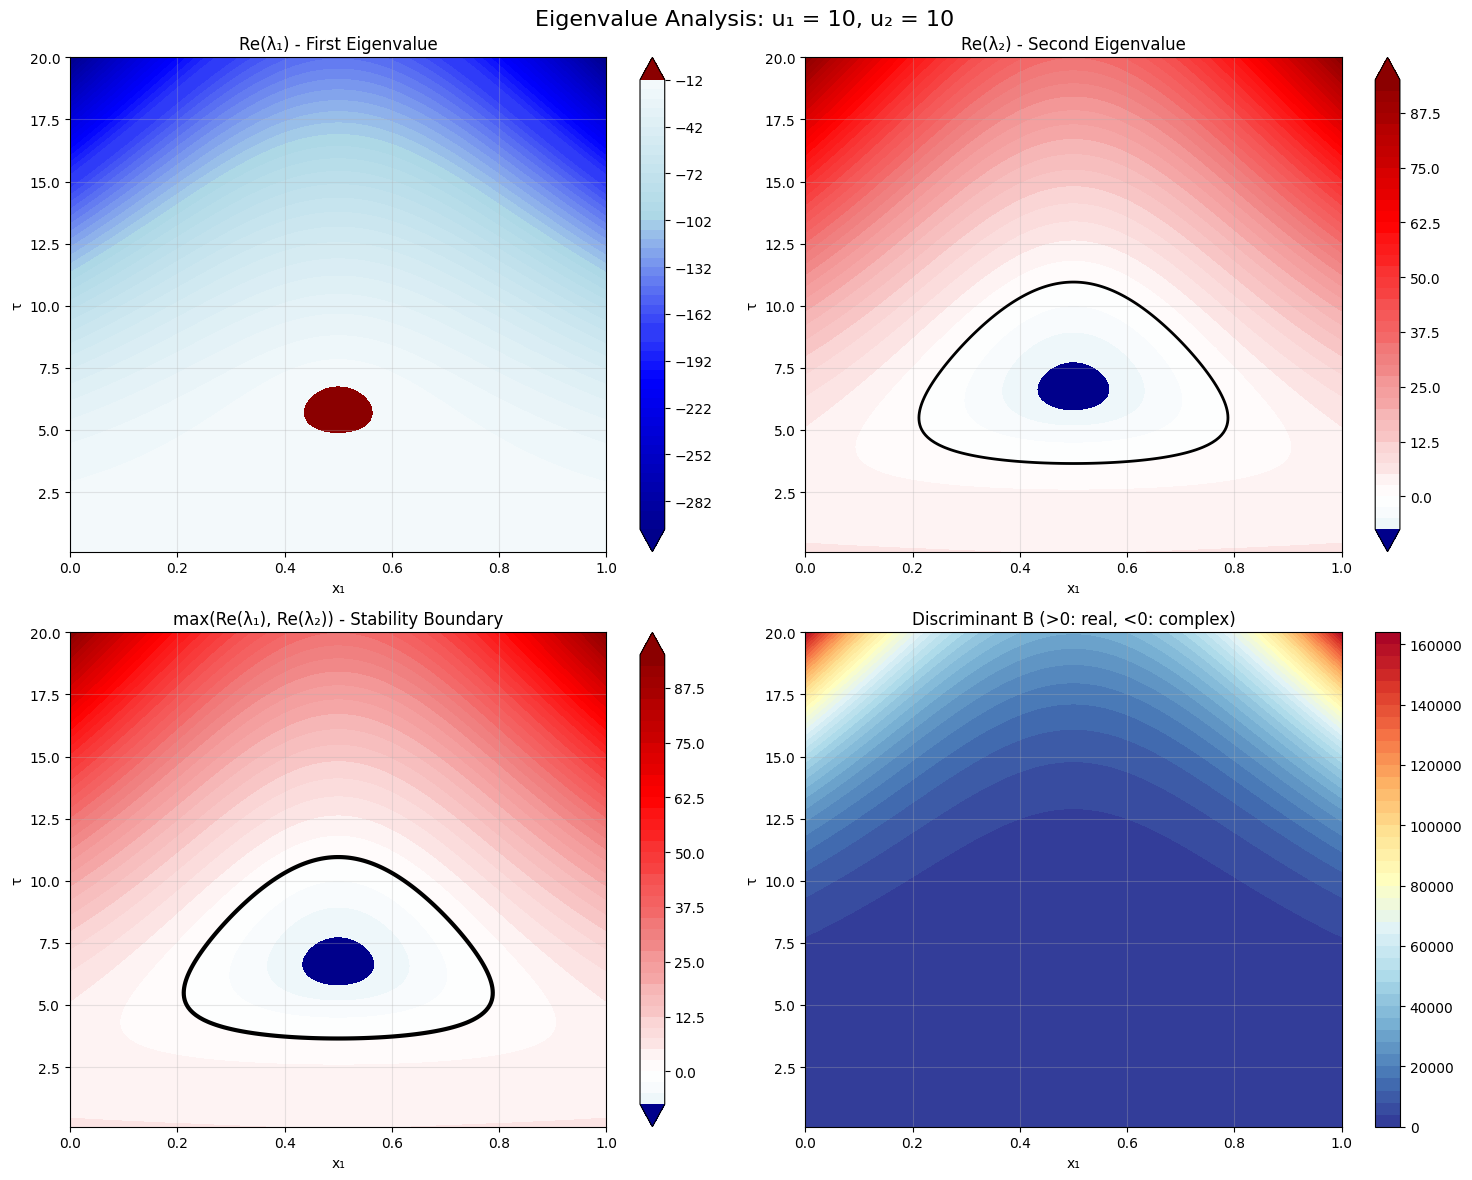

Analysis for u₁ = 10, u₂ = 10:
x₁ range: [0, 1]
τ range: [0.1, 20]

Stability regions (where max real part < 0):
Stable region covers 15.3% of parameter space

Key observations:
- Black contour lines show zero real part (stability boundary)
- Blue regions: stable (negative real parts)
- Red regions: unstable (positive real parts)
- Bottom right plot shows real vs complex eigenvalue regions


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Parameters
u1 = 10
u2 = 10

# Grid ranges
x1_min, x1_max = 0, 1
tau_min, tau_max = 0.1, 20
resolution = 200

# Create meshgrid
x1_vals = np.linspace(x1_min, x1_max, resolution)
tau_vals = np.linspace(tau_min, tau_max, resolution)
X1, TAU = np.meshgrid(x1_vals, tau_vals)

# Calculate eigenvalue components
def calculate_eigenvalues(x1, tau, u1, u2):
    # A term (common part)
    A = -tau**2 * x1**2 + tau**2 * x1 - tau**2/2 - u1/2 - u2/2
    
    # Discriminant B
    B = (4*tau**4*x1**4 - 8*tau**4*x1**3 + 8*tau**4*x1**2 - 4*tau**4*x1 + tau**4 + 
         4*tau**2*u1*x1**2 - 8*tau**2*u1*x1 + 2*tau**2*u1 + 
         4*tau**2*u2*x1**2 - 2*tau**2*u2 + 
         u1**2 + 2*u1*u2 + u2**2 + 16*x1**2 - 16*x1 + 4)
    
    # Handle complex square root
    sqrt_B = np.sqrt(np.abs(B)) * np.sign(B) * (B >= 0) + 1j * np.sqrt(np.abs(B)) * (B < 0)
    
    # Two eigenvalues
    lambda1 = (A - sqrt_B) / 2
    lambda2 = (A + sqrt_B) / 2
    
    return lambda1, lambda2, B

# Calculate eigenvalues over the grid
lambda1, lambda2, discriminant = calculate_eigenvalues(X1, TAU, u1, u2)

# Extract real parts
lambda1_real = np.real(lambda1)
lambda2_real = np.real(lambda2)

# Create the plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle(f'Eigenvalue Analysis: u₁ = {u1}, u₂ = {u2}', fontsize=16)

# Custom colormap: blue (negative) to white (zero) to red (positive)
colors = ['darkblue', 'blue', 'lightblue', 'white', 'lightcoral', 'red', 'darkred']
n_bins = 100
cmap = LinearSegmentedColormap.from_list('stability', colors, N=n_bins)

# Function to create symmetric color limits around zero
def get_symmetric_limits(data):
    abs_max = np.max(np.abs(data))
    return -abs_max, abs_max

# Plot 1: Lambda 1 real part
vmin1, vmax1 = get_symmetric_limits(lambda1_real)
im1 = axes[0,0].contourf(X1, TAU, lambda1_real, levels=50, cmap=cmap, vmin=vmin1, vmax=vmax1, extend='both')
axes[0,0].contour(X1, TAU, lambda1_real, levels=[0], colors='black', linewidths=2)
axes[0,0].set_xlabel('x₁')
axes[0,0].set_ylabel('τ')
axes[0,0].set_title('Re(λ₁) - First Eigenvalue')
axes[0,0].grid(True, alpha=0.3)
plt.colorbar(im1, ax=axes[0,0])

# Plot 2: Lambda 2 real part
vmin2, vmax2 = get_symmetric_limits(lambda2_real)
im2 = axes[0,1].contourf(X1, TAU, lambda2_real, levels=50, cmap=cmap, vmin=vmin2, vmax=vmax2, extend='both')
axes[0,1].contour(X1, TAU, lambda2_real, levels=[0], colors='black', linewidths=2)
axes[0,1].set_xlabel('x₁')
axes[0,1].set_ylabel('τ')
axes[0,1].set_title('Re(λ₂) - Second Eigenvalue')
axes[0,1].grid(True, alpha=0.3)
plt.colorbar(im2, ax=axes[0,1])

# Plot 3: Maximum real part (determines stability)
max_real = np.maximum(lambda1_real, lambda2_real)
vmin3, vmax3 = get_symmetric_limits(max_real)
im3 = axes[1,0].contourf(X1, TAU, max_real, levels=50, cmap=cmap, vmin=vmin3, vmax=vmax3, extend='both')
axes[1,0].contour(X1, TAU, max_real, levels=[0], colors='black', linewidths=3)
axes[1,0].set_xlabel('x₁')
axes[1,0].set_ylabel('τ')
axes[1,0].set_title('max(Re(λ₁), Re(λ₂)) - Stability Boundary')
axes[1,0].grid(True, alpha=0.3)
plt.colorbar(im3, ax=axes[1,0])

# Plot 4: Discriminant (shows real vs complex eigenvalues)
im4 = axes[1,1].contourf(X1, TAU, discriminant, levels=50, cmap='RdYlBu_r')
axes[1,1].contour(X1, TAU, discriminant, levels=[0], colors='black', linewidths=2)
axes[1,1].set_xlabel('x₁')
axes[1,1].set_ylabel('τ')
axes[1,1].set_title('Discriminant B (>0: real, <0: complex)')
axes[1,1].grid(True, alpha=0.3)
plt.colorbar(im4, ax=axes[1,1])

plt.tight_layout()
plt.show()

# Print some analysis
print(f"Analysis for u₁ = {u1}, u₂ = {u2}:")
print(f"x₁ range: [{x1_min}, {x1_max}]")
print(f"τ range: [{tau_min}, {tau_max}]")
print(f"")
print("Stability regions (where max real part < 0):")
stable_mask = max_real < 0
stable_fraction = np.sum(stable_mask) / (resolution * resolution)
print(f"Stable region covers {stable_fraction:.1%} of parameter space")

# Find approximate stability boundaries
print(f"")
print("Key observations:")
print("- Black contour lines show zero real part (stability boundary)")
print("- Blue regions: stable (negative real parts)")
print("- Red regions: unstable (positive real parts)")
print("- Bottom right plot shows real vs complex eigenvalue regions")

In [27]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
from functools import partial


class LinearSystem:
    def __init__(
        self,
        u_func,
        tau=1.0,
        x1_init=0.5,
        noise_std=0,
        off_diagonal_weight_perturbation=0,
        learning_rate=1,
        homeo_rate=0.05,
        alpha=1,
        w_11=None,
        w_22=None,
        w_12=None,
        w_21=None,
    ):
        """
        Initialize the 2D linear system
        
        Parameters:
        u_func: function that takes time t and returns input vector [u1(t), u2(t)]
                or array-like for constant input (backward compatibility)
        tau: float, time constant parameter
        """
        # Handle both function and constant input for backward compatibility
        if callable(u_func):
            self.u_func = u_func
            self.u_constant = None
        else:
            # Convert constant input to function
            u_array = np.array(u_func)
            self.u_func = lambda t: u_array
            self.u_constant = u_array
            
        self.tau = tau
        self.learning_rate = learning_rate
        self.homeo_rate = homeo_rate
        self.alpha = alpha
        
        # Initial conditions based on your specification
        if w_11 is None:
            w_11 = 1.5 + np.random.normal(loc=0, scale=off_diagonal_weight_perturbation)
        if w_22 is None:
            w_22 = 1.5 + np.random.normal(loc=0, scale=off_diagonal_weight_perturbation)

        if w_12 is None:
            w_12 = (1.5 - 1) + np.random.normal(loc=0, scale=off_diagonal_weight_perturbation)
        if w_21 is None:
            w_21 = (1.5 - 1) + np.random.normal(loc=0, scale=off_diagonal_weight_perturbation)

        self.W0 = np.array([[w_11, w_12],
                           [w_21, w_22]])
        
        # x_j = 1 - x_i (assuming some initial values)
        self.x0 = np.clip(np.array([x1_init, 1 - x1_init]) + np.random.normal(loc=np.zeros(2), scale=np.ones(2) * noise_std), 0, 1)
    
    def system_dynamics(self, state, t):
        """
        Define the system of differential equations
        
        state = [x1, x2, w11, w12, w21, w22]
        """
        x1, x2, w11, w12, w21, w22 = state
        
        # Current state vector and weight matrix
        x = np.clip(np.array([x1, x2]), 0, None)
        W = np.array([[w11, w12], [w21, w22]])

        w_inh_1 = 1
        w_inh_2 = 1.25
        w_inh = np.array([[w_inh_1, w_inh_1], [w_inh_2, w_inh_2]])

        # Get time-varying input
        u_t = np.array(self.u_func(t))
        
        # State dynamics: dx/dt = Wx - x + u(t) (now time-varying)
        dx_dt = (W - w_inh) @ x - x + u_t
        dx_dt = np.where(np.logical_and(x <= 0, dx_dt < 0), 0, dx_dt)
        dx1_dt, dx2_dt = dx_dt
        
        # Weight dynamics: dw_ij/dt = tau^2 * [dx_i/dt * x_j - x_i * dx_j/dt] - x_i(1-x_i) + x_j(1-x_j)
        homeo_rate = self.homeo_rate
        input_off = np.isclose(np.array(self.u_func(t+10)), 0) | np.isclose(np.array(self.u_func(t)), 0)
        if self.learning_rate == 0 or input_off.all():
            dw11_dt, dw12_dt, dw21_dt, dw22_dt = 0, 0, 0, 0
        else:
            z = 0.05 * np.maximum(u_t - 0.5, 0)
#             dw11_dt = self.learning_rate * (self.tau**2 * (z[0] * x[0] - dx1_dt * x[0] + x[0] * dx1_dt) + homeo_rate * (2 - w11 - w21))
#             dw12_dt = self.learning_rate * (self.tau**2 * (z[0] * x[1] - dx1_dt * x[1] + x[0] * dx2_dt) + homeo_rate * (2 - w22 - w12))
#             dw21_dt = self.learning_rate * (self.tau**2 * (z[1] * x[0] - dx2_dt * x[0] + x[1] * dx1_dt) + homeo_rate * (2 - w11 - w21))
#             dw22_dt = self.learning_rate * (self.tau**2 * (z[1] * x[1] - dx2_dt * x[1] + x[1] * dx2_dt) + homeo_rate * (2 - w22 - w12))

            dw11_dt = self.learning_rate * (self.tau**2 * (self.alpha * z[0] * x[0] - dx1_dt * x[0]) + homeo_rate * (2 - w11 - w21))
            dw12_dt = self.learning_rate * (self.tau**2 * (self.alpha * z[0] * x[1] - dx1_dt * x[1]) + homeo_rate * (2 - w22 - w12))
            dw21_dt = self.learning_rate * (self.tau**2 * (self.alpha * z[1] * x[0]- dx2_dt * x[0]) + homeo_rate * (2 - w11 - w21))
            dw22_dt = self.learning_rate * (self.tau**2 * (self.alpha * z[1] * x[1]- dx2_dt * x[1]) + homeo_rate * (2 - w22 - w12))
        
        return [dx1_dt, dx2_dt, dw11_dt, dw12_dt, dw21_dt, dw22_dt]
    
    def simulate(self, t_span, dt=0.002):
        """
        Simulate the system over time
        
        Parameters:
        t_span: tuple, (start_time, end_time)
        dt: float, time step
        """
        t = np.arange(t_span[0], t_span[1], dt)
        
        # Initial state vector
        initial_state = [self.x0[0], self.x0[1], 
                        self.W0[0,0], self.W0[0,1], self.W0[1,0], self.W0[1,1]]
        
        # Solve the ODE system
        solution = odeint(self.system_dynamics, initial_state, t)
        
        # Extract results
        x1, x2 = solution[:, 0], solution[:, 1]
        w11, w12, w21, w22 = solution[:, 2], solution[:, 3], solution[:, 4], solution[:, 5]
        
        # Also compute the input over time for plotting
        u_history = np.array([self.u_func(time) for time in t])
        
        return t, x1, x2, w11, w12, w21, w22, u_history

# Modified simulation function
def run_simulation(
    u_funcs=None,
    x1_init_values=None,
    learning_rate=1,
    homeo_rate=0.05,
    alpha=1,
    seed=None,
    t_sim=(0, 200),
    weight_perturbation=0,
    color_by=None,
    reinitialize=False,
    noise_std=0,
):
    """
    Run simulation with time-varying input
    
    Parameters:
    u_func: function that takes time t and returns [u1(t), u2(t)]
           if None, uses constant input [0.5, 0.5]
    """
    
    tau = 2.0  # Time constant
    
    # Multiple initial conditions for x1_init
    if seed:
        np.random.seed(seed)

    if x1_init_values is None:
        x1_init_values = np.clip(np.linspace(0.05, 0.95, 30), 0, 1)

    # Default to constant input for backward compatibility
    if u_funcs is None:
        u_funcs = [lambda t: [0.5, 0.5]] * len(x1_init_values)

    if color_by is None:
        colors = plt.cm.viridis(np.linspace(0, 1, len(x1_init_values)))
    else:
        m = np.abs(color_by).max()
        colors = plt.cm.viridis(0.5 * (1 + color_by/m))
    
    # Storage for all simulations
    all_results = []
    all_results_2 = []
    
    # Set up the plot (now 2x3 to include input plot)
    scale = 0.75
    fig, axes = plt.subplots(2, 3, figsize=(15 * scale, 10 * scale))
    fig.suptitle(f'Time-Varying Input System (τ={tau})', 
                 fontsize=16, fontweight='bold')
    
    print(f"Running simulations for {len(x1_init_values)} initial conditions...")

    axes[0, 1].plot([1, 0], [0, 1], '--', c='gray')

    if reinitialize:
        fig2, axes2 = plt.subplots(2, 3, figsize=(15 * scale, 10 * scale))
        fig2.suptitle(f'Time-Varying Input System (τ={tau})', 
                     fontsize=16, fontweight='bold')
        axes2[0, 1].plot([1, 0], [0, 1], '--', c='gray')
    
    # Plot input function first (same for all trajectories)
    t_input = np.arange(t_sim[0], t_sim[1], 0.002)
    # u_input_history = np.array([u_func(t) for t in t_input])
    # axes[0, 2].plot(t_input, u_input_history[:, 0], 'r-', linewidth=2, label='u₁(t)')
    # axes[0, 2].plot(t_input, u_input_history[:, 1], 'b-', linewidth=2, label='u₂(t)')
    
    for i, (x1_init, color) in enumerate(zip(x1_init_values, colors)):
        # Create system with this initial condition and time-varying input
        system = LinearSystem(u_funcs[i], tau, x1_init=x1_init, noise_std=noise_std, 
                            off_diagonal_weight_perturbation=weight_perturbation, 
                            learning_rate=learning_rate, homeo_rate=homeo_rate, alpha=alpha)
        
        # Simulate
        t, x1, x2, w11, w12, w21, w22, u_history = system.simulate(t_sim, dt=0.002)
        all_results.append((t, x1, x2, w11, w12, w21, w22, u_history))
        
        # Plot state variables
        axes[0, 0].plot(t, x1, color=color, linewidth=1.5, alpha=0.8)
        # axes[0, 0].plot(t, x2, color=color, linewidth=1.5, alpha=0.6, linestyle='--')
        
        # Phase portrait
        axes[0, 1].plot(x1, x2, color=color, linewidth=2, alpha=0.8)
        axes[0, 1].scatter(x1[0], x2[0], marker='o', edgecolor=color, facecolor='none', s=50, alpha=0.8)
        axes[0, 1].scatter(x1[-1], x2[-1], marker='o', color=color, s=50, alpha=0.8)
        
        axes[0, 2].scatter([x1[-1]], [color_by[i]], color='black')
        
        # Weight matrix diagonal elements
        axes[1, 0].plot(t, w11, color=color, linewidth=1.5, alpha=0.8)
        axes[1, 0].plot(t, w22, color=color, linewidth=1.5, alpha=0.8, linestyle='--')
        
        # Off-diagonal weights
        axes[1, 1].plot(t, w12, color=color, linewidth=1.5, alpha=0.8)
        axes[1, 1].plot(t, w21, color=color, linewidth=1.5, alpha=0.8, linestyle='--')

        # Calculate weight differences
        w22_minus_w12 = w22 - w12
        w11_minus_w21 = w11 - w21
        
        axes[1, 2].plot(t, w22_minus_w12, color=color, linewidth=1.5, alpha=0.8)
        axes[1, 2].plot(t, w11_minus_w21, color=color, linewidth=1.5, alpha=0.8, linestyle='--')

        if reinitialize:
            # Create system with this initial condition and time-varying input
            x1_reinit = np.random.rand() * 0.9 + 0.05
    
            system = LinearSystem(u_funcs[i], tau, x1_init=x1_reinit, noise_std=noise_std, 
                                off_diagonal_weight_perturbation=weight_perturbation, 
                                learning_rate=learning_rate, homeo_rate=homeo_rate,
                                w_11=w11[-1], w_22=w22[-1], w_12=w12[-1], w_21=w21[-1])
            
            # Simulate
            t, x1, x2, w11, w12, w21, w22, u_history = system.simulate(t_sim, dt=0.002)
    
            # Plot state variables
            axes2[0, 0].plot(t, x1, color=color, linewidth=1.5, alpha=0.8)
            # axes2[0, 0].plot(t, x2, color=color, linewidth=1.5, alpha=0.6, linestyle='--')
            
            # Phase portrait
            axes2[0, 1].plot(x1, x2, color=color, linewidth=2, alpha=0.8)
            axes2[0, 1].scatter(x1[0], x2[0], marker='o', edgecolor=color, facecolor='none', s=50, alpha=0.8)
            axes2[0, 1].scatter(x1[-1], x2[-1], marker='o', color=color, s=50, alpha=0.8)
            
            # Weight matrix diagonal elements
            axes2[1, 0].plot(t, w11, color=color, linewidth=1.5, alpha=0.15)
            axes2[1, 0].plot(t, w22, color=color, linewidth=1.5, alpha=0.15, linestyle='--')
            
            # Off-diagonal weights
            axes2[1, 1].plot(t, w12, color=color, linewidth=1.5, alpha=0.15)
            axes2[1, 1].plot(t, w21, color=color, linewidth=1.5, alpha=0.15, linestyle='--')
    
            # Calculate weight differences
            w22_minus_w12 = w22 - w12
            w11_minus_w21 = w11 - w21
            
            axes2[1, 2].plot(t, w22_minus_w12, color=color, linewidth=1.5, alpha=0.15)
            axes2[1, 2].plot(t, w11_minus_w21, color=color, linewidth=1.5, alpha=0.15, linestyle='--')
    
    
    # Configure all subplots
    axes[0, 0].set_xlabel('Time')
    axes[0, 0].set_ylabel('State Variables')
    axes[0, 0].set_title('State Evolution (solid=x₁, dashed=x₂)')
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].set_xlabel('x₁')
    axes[0, 1].set_ylabel('x₂')
    axes[0, 1].set_title('Phase Portraits (○=start, ●=end)')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_xlim(-0.1, 1.5)
    axes[0, 1].set_ylim(-0.1, 1.5)
    
#     axes[0, 2].set_xlabel('Time')
#     axes[0, 2].set_ylabel('Input')
#     axes[0, 2].set_title('Time-Varying Input u(t)')
    axes[0, 2].grid(True, alpha=0.3)
#     axes[0, 2].legend()
    
    axes[1, 0].set_xlabel('Time')
    axes[1, 0].set_ylabel('Diagonal Weights')
    axes[1, 0].set_title('Diagonal Weights (solid=w₁₁, dashed=w₂₂)')
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].set_xlabel('Time')
    axes[1, 1].set_ylabel('Off-diagonal Weights')
    axes[1, 1].set_title('Off-diagonal Weights (solid=w₁₂, dashed=w₂₁)')
    axes[1, 1].grid(True, alpha=0.3)
    
    axes[1, 2].set_xlabel('Time')
    axes[1, 2].set_ylabel('Weight Differences')
    axes[1, 2].set_title('Weight Differences (solid=w₂₂-w₁₂, dashed=w₁₁-w₂₁)')
#     axes[1, 2].set_ylim(0.9, 1.1)
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()

    if reinitialize:
        # Configure all subplots
        axes2[0, 0].set_xlabel('Time')
        axes2[0, 0].set_ylabel('State Variables')
        axes2[0, 0].set_title('State Evolution (solid=x₁, dashed=x₂)')
        axes2[0, 0].grid(True, alpha=0.3)
        
        axes2[0, 1].set_xlabel('x₁')
        axes2[0, 1].set_ylabel('x₂')
        axes2[0, 1].set_title('Phase Portraits (○=start, ●=end)')
        axes2[0, 1].grid(True, alpha=0.3)
        axes2[0, 1].set_xlim(-0.1, 1.5)
        axes2[0, 1].set_ylim(-0.1, 1.5)
        
        axes2[0, 2].set_xlabel('Time')
        axes2[0, 2].set_ylabel('Input')
        axes2[0, 2].set_title('Time-Varying Input u(t)')
        axes2[0, 2].grid(True, alpha=0.3)
        axes2[0, 2].legend()
        
        axes2[1, 0].set_xlabel('Time')
        axes2[1, 0].set_ylabel('Diagonal Weights')
        axes2[1, 0].set_title('Diagonal Weights (solid=w₁₁, dashed=w₂₂)')
        axes2[1, 0].grid(True, alpha=0.3)
        
        axes2[1, 1].set_xlabel('Time')
        axes2[1, 1].set_ylabel('Off-diagonal Weights')
        axes2[1, 1].set_title('Off-diagonal Weights (solid=w₁₂, dashed=w₂₁)')
        axes2[1, 1].grid(True, alpha=0.3)
        
        axes2[1, 2].set_xlabel('Time')
        axes2[1, 2].set_ylabel('Weight Differences')
        axes2[1, 2].set_title('Weight Differences (solid=w₂₂-w₁₂, dashed=w₁₁-w₂₁)')
        axes2[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return all_results


Running simulations for 30 initial conditions...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


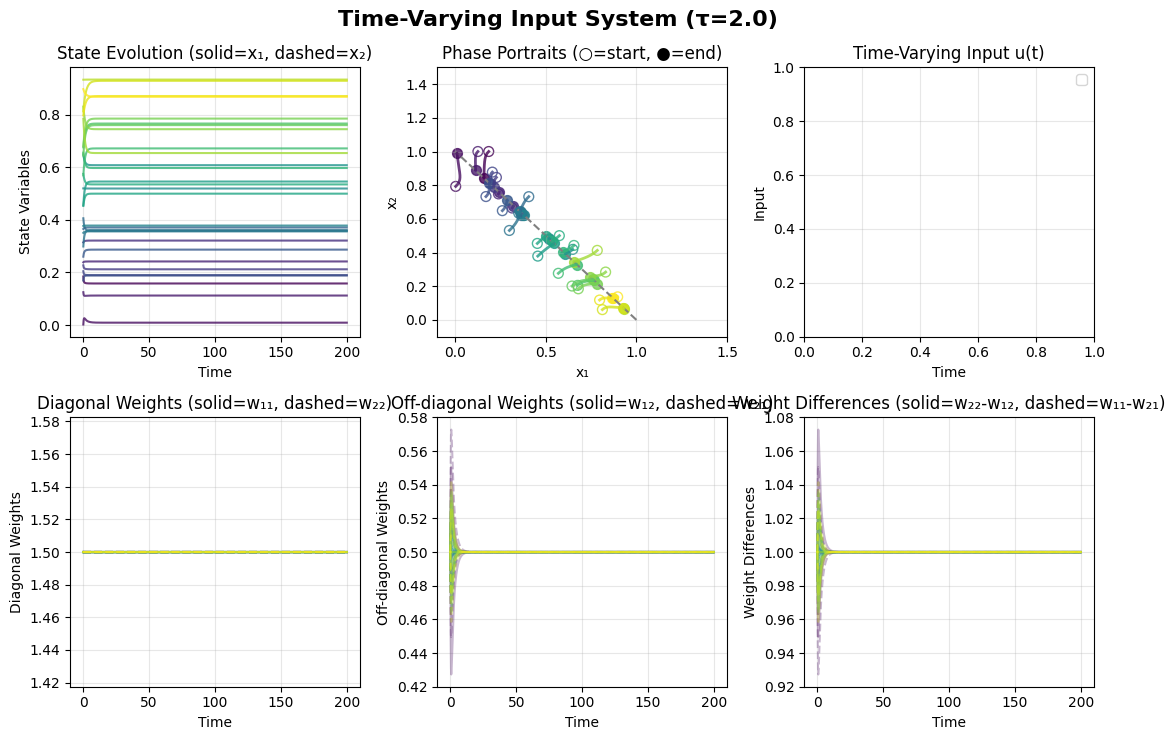

In [3]:
run_simulation(homeo_rate=0, seed=13, noise_std=0.1)
None

Running simulations for 30 initial conditions...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


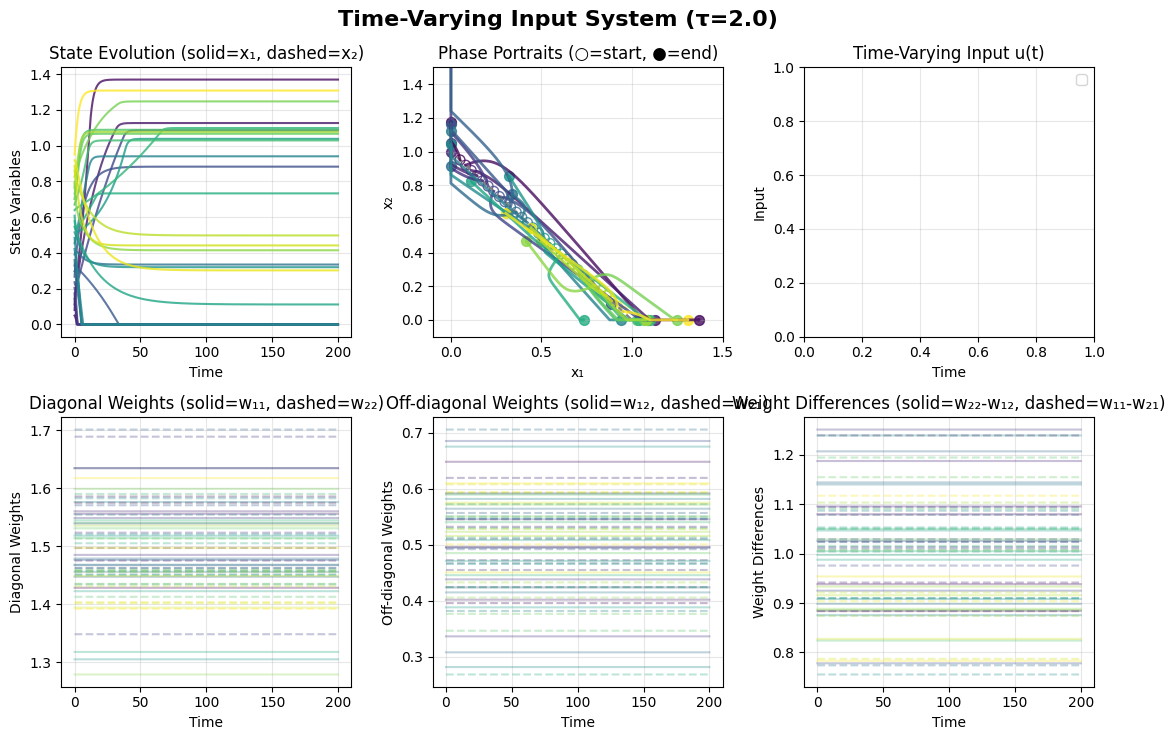

In [5]:
run_simulation(homeo_rate=0, learning_rate=0, seed=13, weight_perturbation=0.1)
None

Running simulations for 30 initial conditions...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


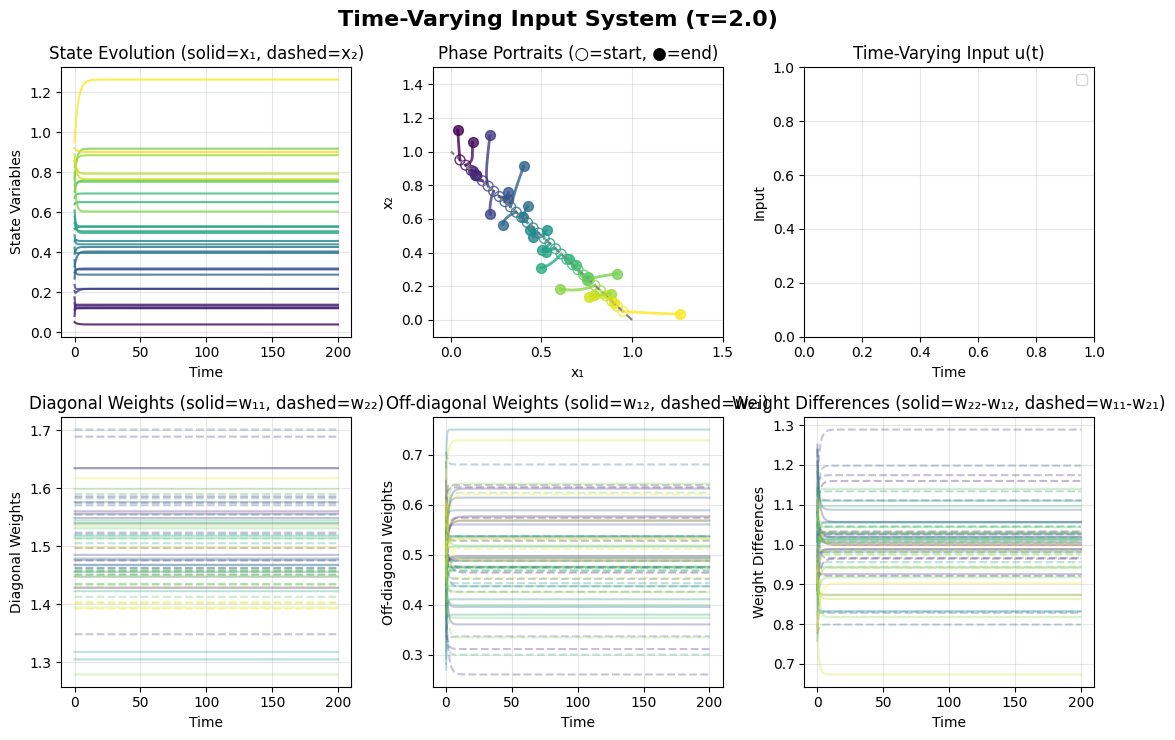

In [6]:
run_simulation(homeo_rate=0, learning_rate=1, seed=13, weight_perturbation=0.1)
None

Running simulations for 30 initial conditions...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


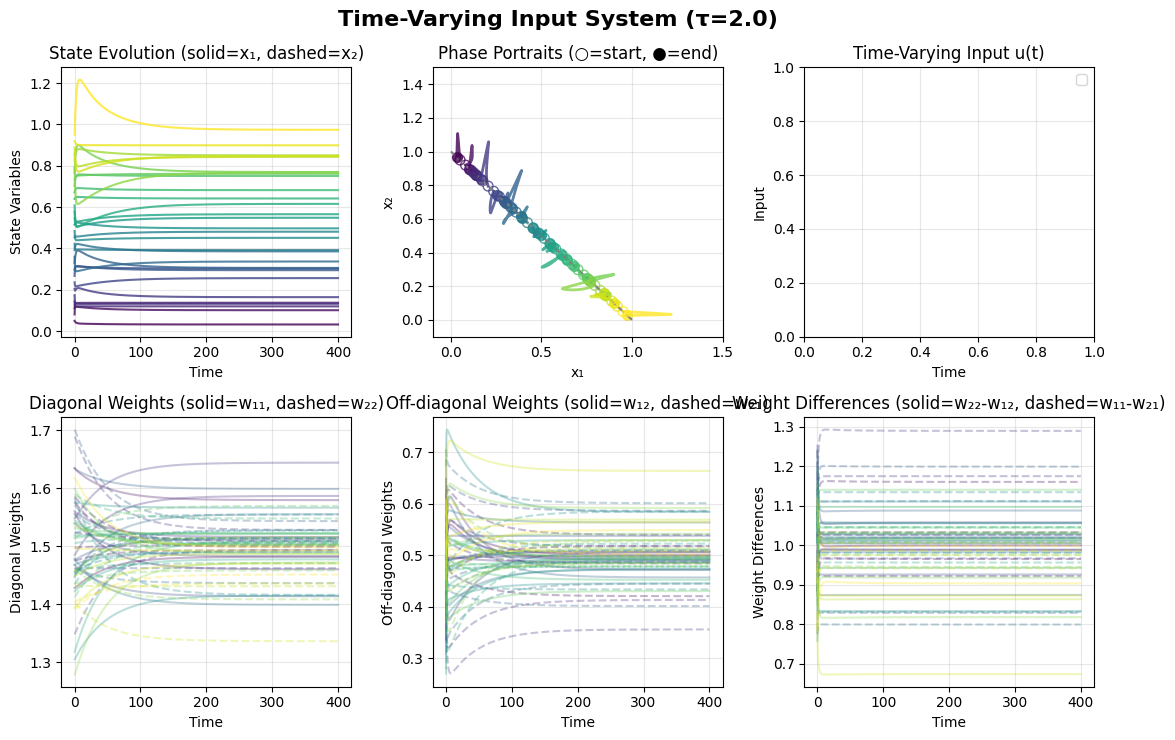

In [7]:
run_simulation(homeo_rate=0.01, learning_rate=1, seed=13, weight_perturbation=0.1, t_sim=(0, 400))
None

Running simulations for 30 initial conditions...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


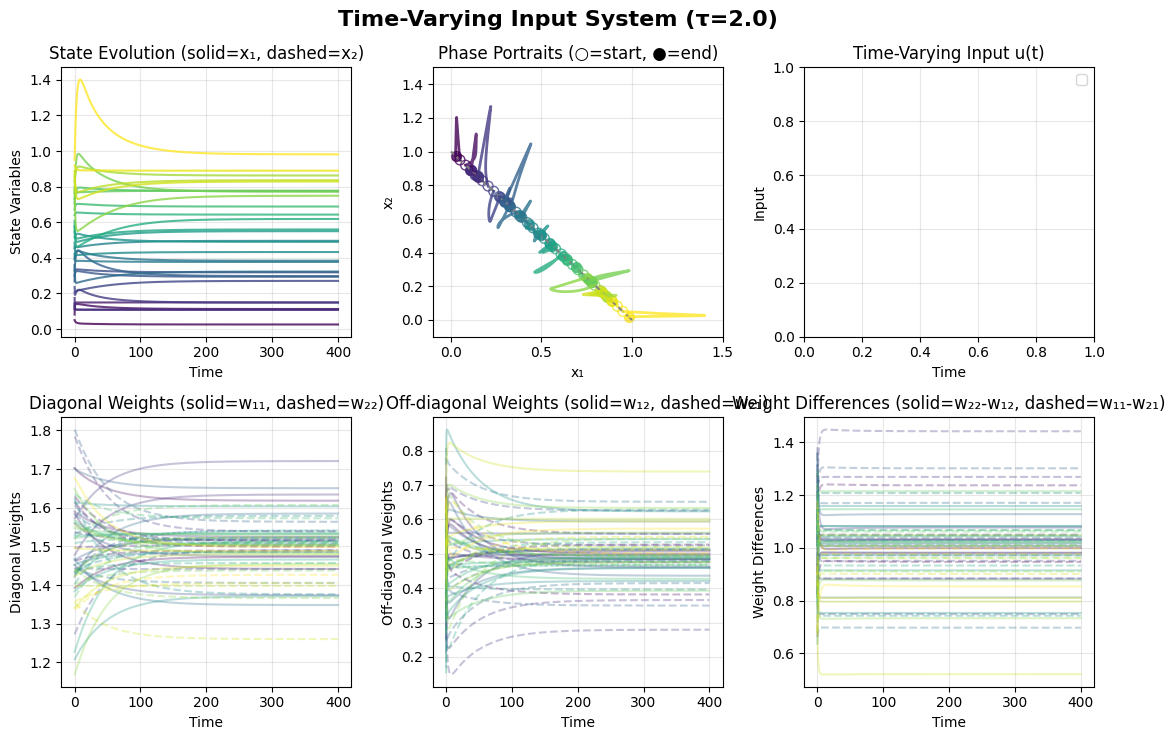

In [8]:
run_simulation(homeo_rate=0.01, learning_rate=1, seed=13, weight_perturbation=0.15, t_sim=(0, 400))
None

Running simulations for 30 initial conditions...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


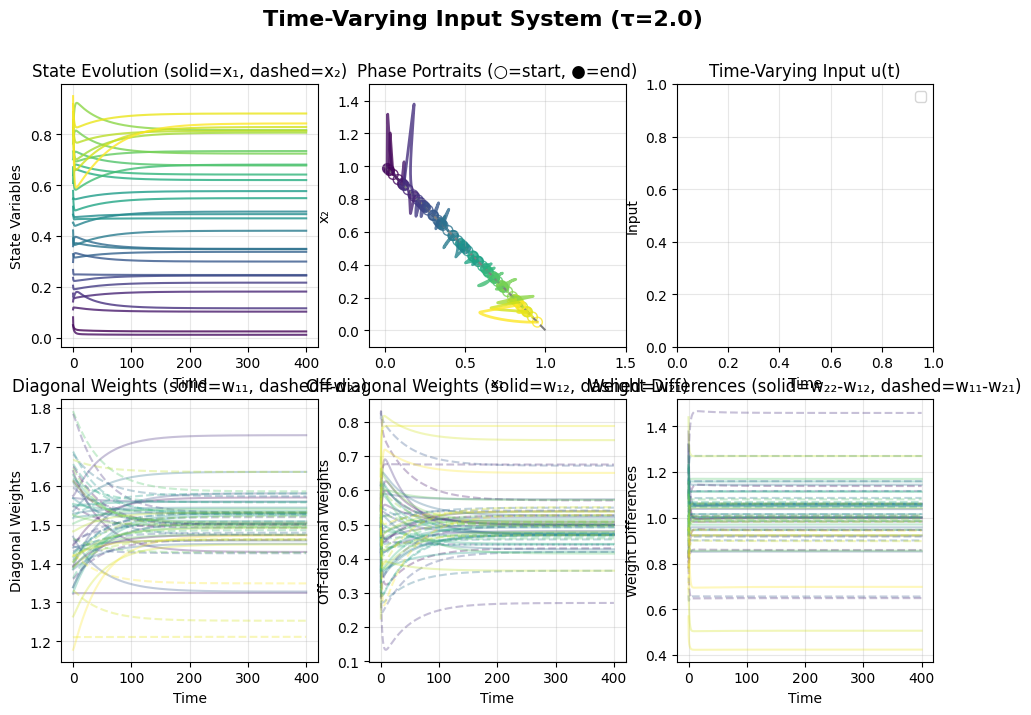

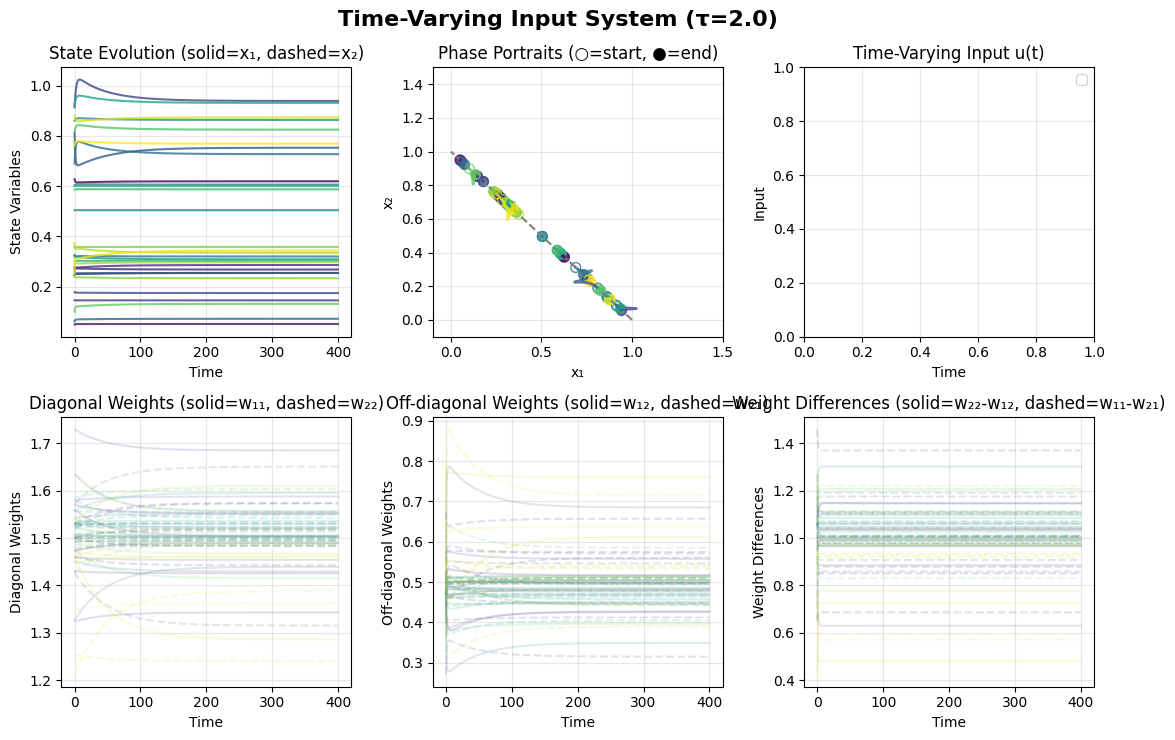

In [9]:
run_simulation(homeo_rate=0.01, learning_rate=1, seed=13, weight_perturbation=0.15, t_sim=(0, 400), reinitialize=True)
None

Running simulations for 20 initial conditions...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


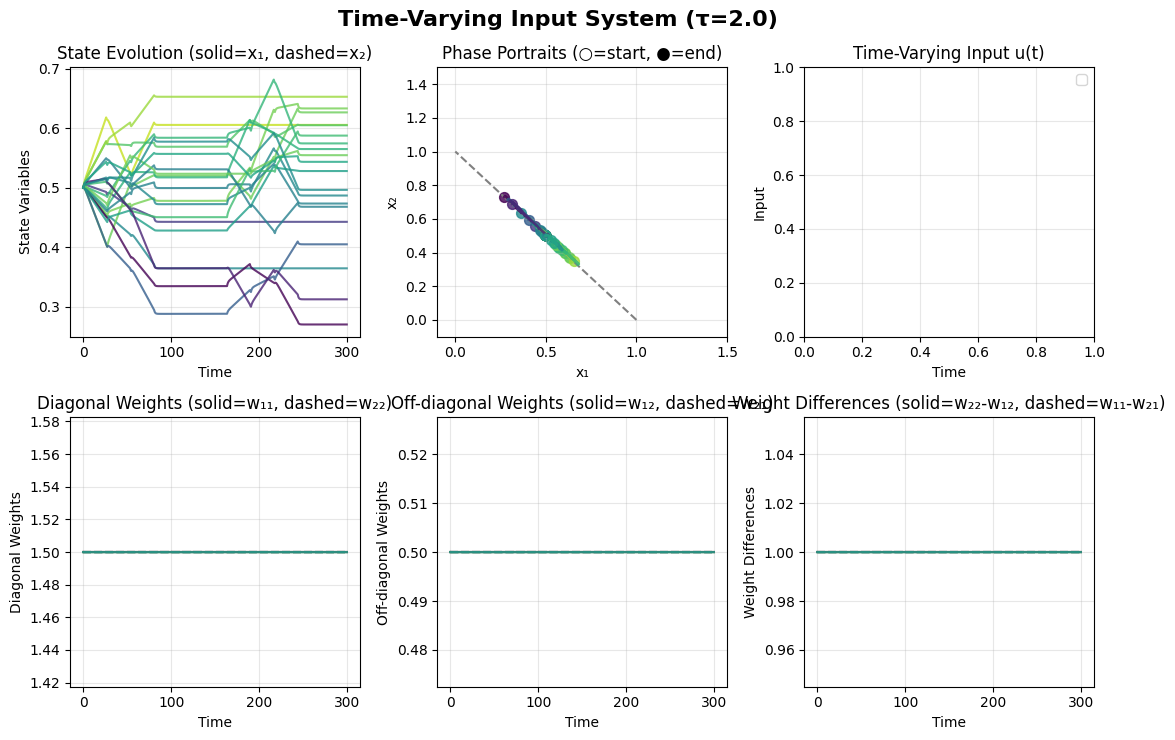

In [10]:
from functools import partial

dt = 0.002

x1s = np.ones((20)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if t_p < 75 or (t_p >= 150 and t_p < 225):
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.01 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(20, np.arange(0, 300, dt), dt=dt)
    
run_simulation(
    homeo_rate=0,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=0,
    seed=13,
    weight_perturbation=0,
    t_sim=(0, 300),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
)
None

Running simulations for 10 initial conditions...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


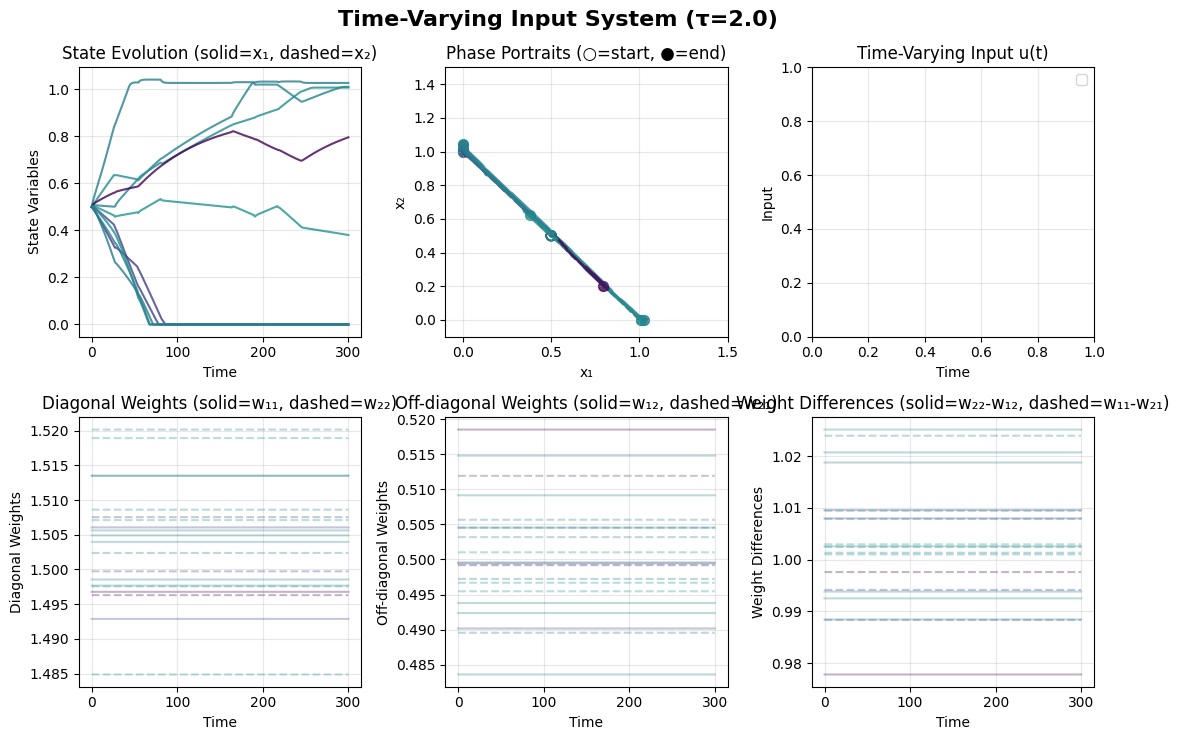

In [11]:
from functools import partial

dt = 0.002

x1s = np.ones((10)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if t_p < 75 or (t_p >= 150 and t_p < 225):
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.01 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(10, np.arange(0, 300, dt), dt=dt)
    
run_simulation(
    homeo_rate=0,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=0,
    seed=13,
    weight_perturbation=0.01,
    t_sim=(0, 300),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
)
None

Running simulations for 10 initial conditions...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


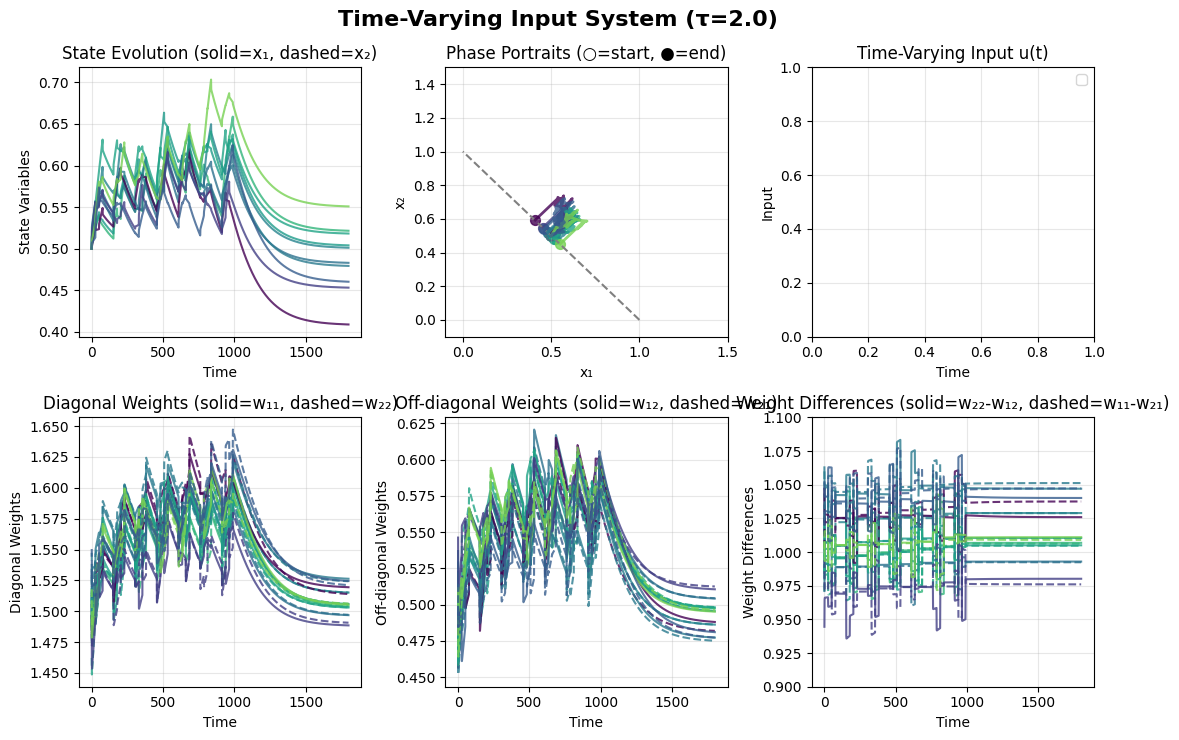

In [11]:
np.random.seed(100)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 1800, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.01,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=1,
    seed=13,
    weight_perturbation=0.025,
    t_sim=(0, 1800),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
)
None

Running simulations for 10 initial conditions...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


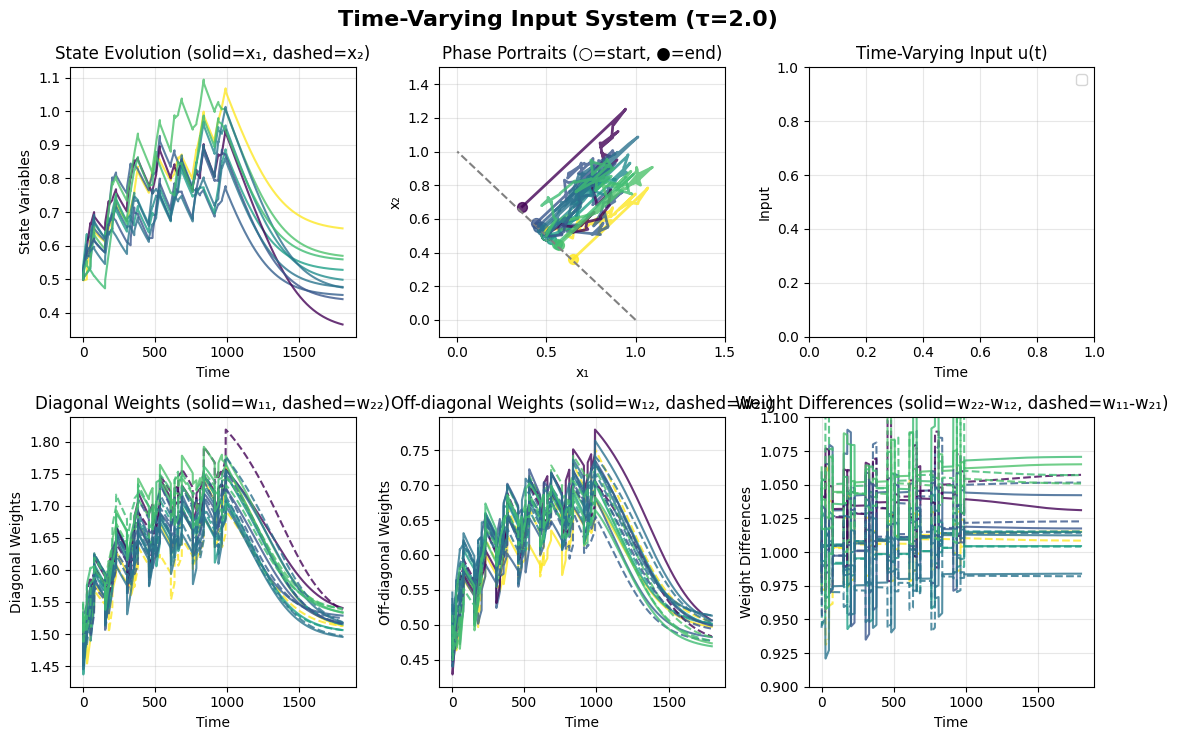

In [9]:
np.random.seed(105)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.1 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 1800, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.01,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=1,
    seed=13,
    weight_perturbation=0.025,
    t_sim=(0, 1800),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
)
None

Running simulations for 10 initial conditions...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


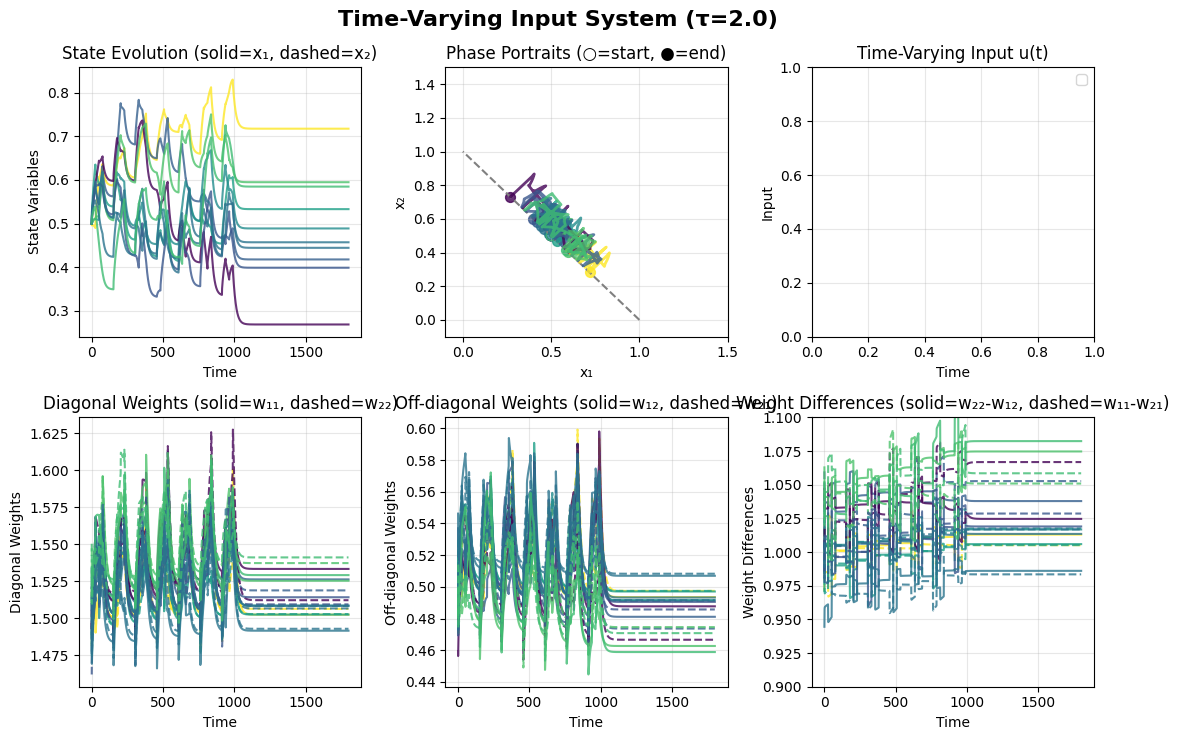

In [17]:
np.random.seed(105)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 1800, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=1,
    alpha=3,
    seed=13,
    weight_perturbation=0.025,
    t_sim=(0, 1800),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
)
None

Running simulations for 10 initial conditions...


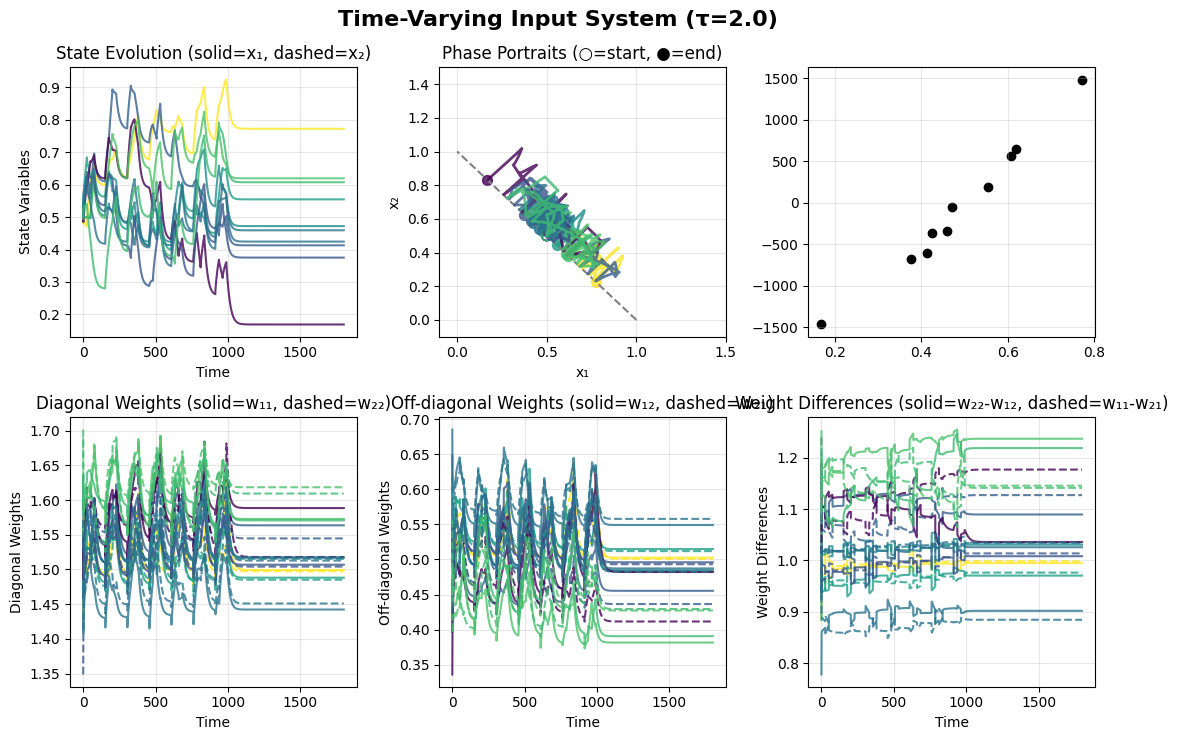

In [26]:
np.random.seed(105)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 1800, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=1,
    alpha=4,
    seed=13,
    weight_perturbation=0.1,
    t_sim=(0, 1800),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
)
None

Running simulations for 10 initial conditions...


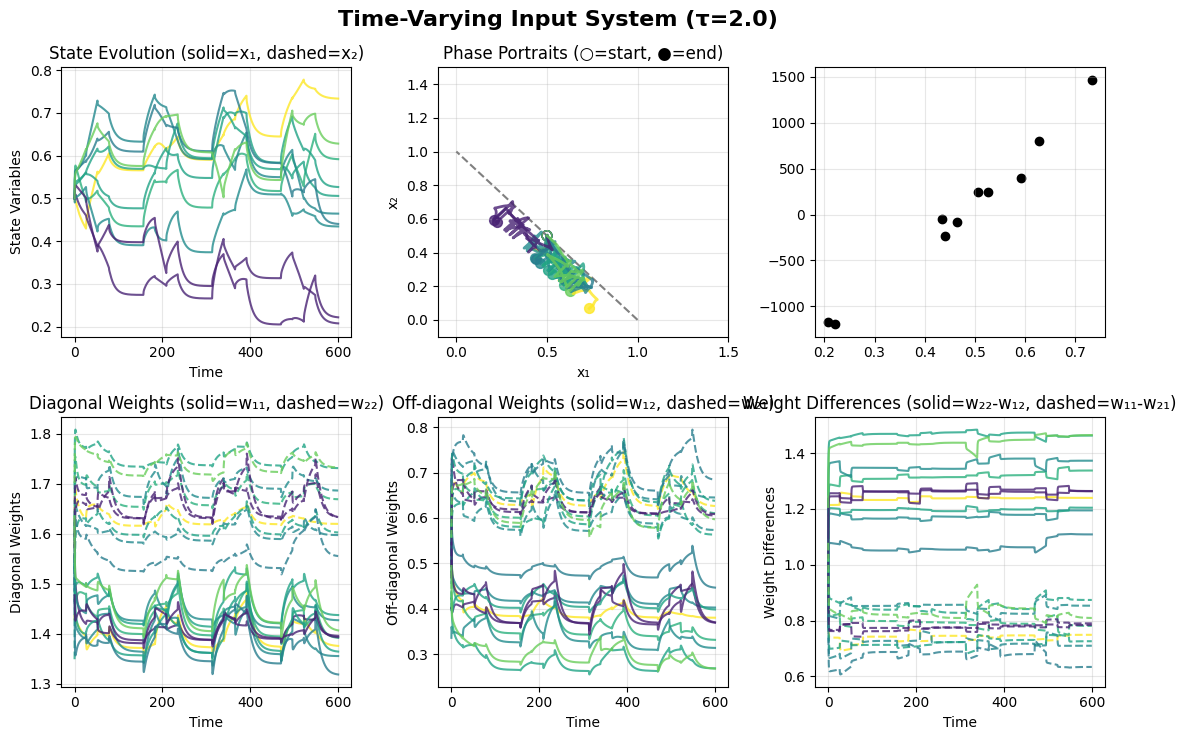

In [29]:
np.random.seed(105)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 600, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=1,
    alpha=4,
    seed=13,
    weight_perturbation=0.1,
    t_sim=(0, 600),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
)
None

In [ ]:
np.random.seed(105)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 1800, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.1,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=1,
    seed=13,
    weight_perturbation=0.025,
    t_sim=(0, 1800),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
)
None

In [ ]:
dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 1200, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.01,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=1,
    seed=13,
    weight_perturbation=0.01,
    t_sim=(0, 1200),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
)
None

Running simulations for 10 initial conditions...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


In [ ]:
np.random.seed(100)

dt = 0.002
n = 10

x1s = np.ones((n)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_inps = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        for t_p in np.linspace(0, t.max(), int((t.max() + 1)/block_len)):
            if (t_p % 150) < 75 and t_p < 1000:
                u_block = np.random.rand(2)
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = 0.05 * u_block[:, None]
        all_inps.append(inp)
        funcs.append(partial(u_func, inp=inp + 0.5))
    return funcs, all_inps

u_funcs, all_inps = make_u_funcs(n, np.arange(0, 1200, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.01,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=1,
    seed=100,
    weight_perturbation=0.01,
    t_sim=(0, 1200),
    color_by=np.array([(inp[0].sum() - inp[1].sum()) for inp in all_inps]),
    noise_std=0,
)
None

Running simulations for 10 initial conditions...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Running simulations for 15 initial conditions...


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


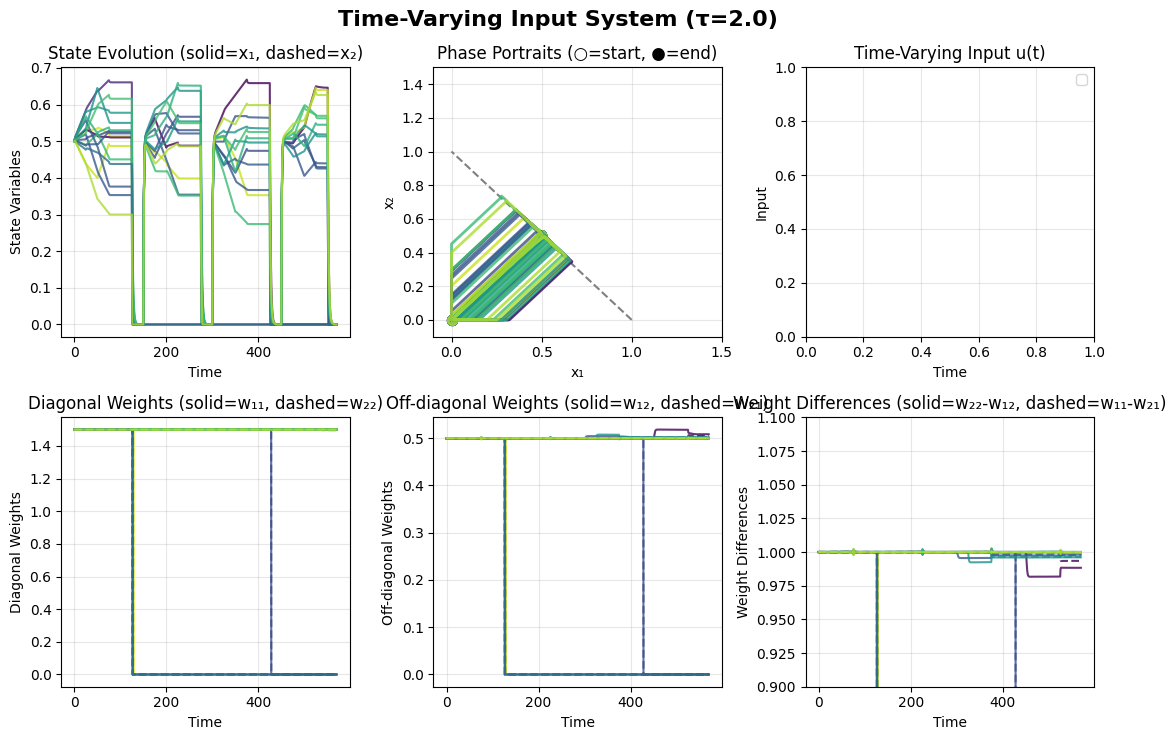

In [68]:
from functools import partial

dt = 0.002
N = 15

x1s = np.ones((N)) * 0.5

def make_u_funcs(n, t, dt):    
    def u_func(t_prime, inp):
        return np.stack([
            np.interp(t_prime, t, inp[0, :]),
            np.interp(t_prime, t, inp[1, :]),
        ])

    funcs = []
    all_tds = []

    for i in range(n):
        block_len = 25
        inp = np.zeros((2, len(t)))
        target_diffs = np.zeros((2, len(t)))
        for t_p in np.arange(int((t.max() + 1)/block_len)) * 25:
            if (t_p % 150) < 75:
                inputs_to_integrate = 0.01 * np.random.rand(2)
                target_diffs[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = inputs_to_integrate[:, None]
                u_block = inputs_to_integrate + 0.5
            elif (t_p % 150) >= 75 and (t_p % 150) < 125:
                u_block = np.zeros((2)) + 0.5
            else:
                u_block = np.zeros((2))
            inp[:, int(t_p/dt):int((t_p + block_len+1)/dt)] = u_block[:, None]
        all_tds.append(target_diffs)
        funcs.append(partial(u_func, inp=inp))
    return funcs, all_tds

u_funcs, target_diffs = make_u_funcs(N, np.arange(0, 570, dt), dt=dt)
    
run_simulation(
    homeo_rate=0.025,
    u_funcs=u_funcs,
    x1_init_values=x1s,
    learning_rate=1,
    seed=13,
    weight_perturbation=0,
    t_sim=(0, 570),
    color_by=np.array([(tds[0, int(-150/dt):].sum() - tds[1, int(-150/dt):].sum()) for tds in target_diffs]),
    noise_std=0,
)
None

In [ ]:
# run_simulation(learning_rate=0, t_sim=(0, 5), seed=12)
None

Running simulations for 30 initial conditions...


/tmp/ipykernel_1033294/59156352.py:95: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  solution = odeint(self.system_dynamics, initial_state, t)


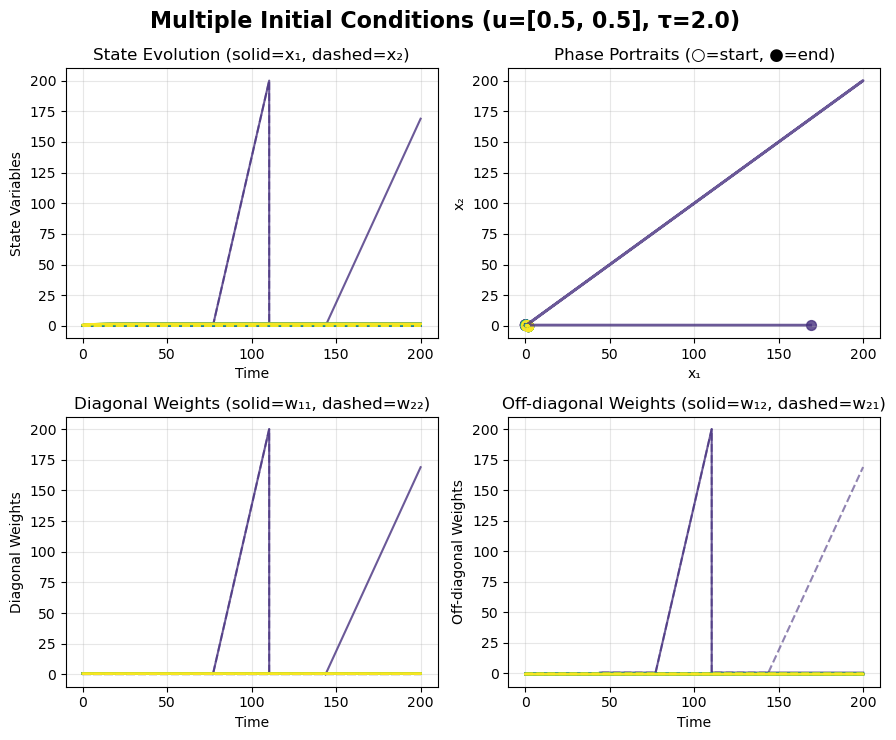

In [86]:
run_simulation(learning_rate=0)
None

Running simulations for 30 initial conditions...


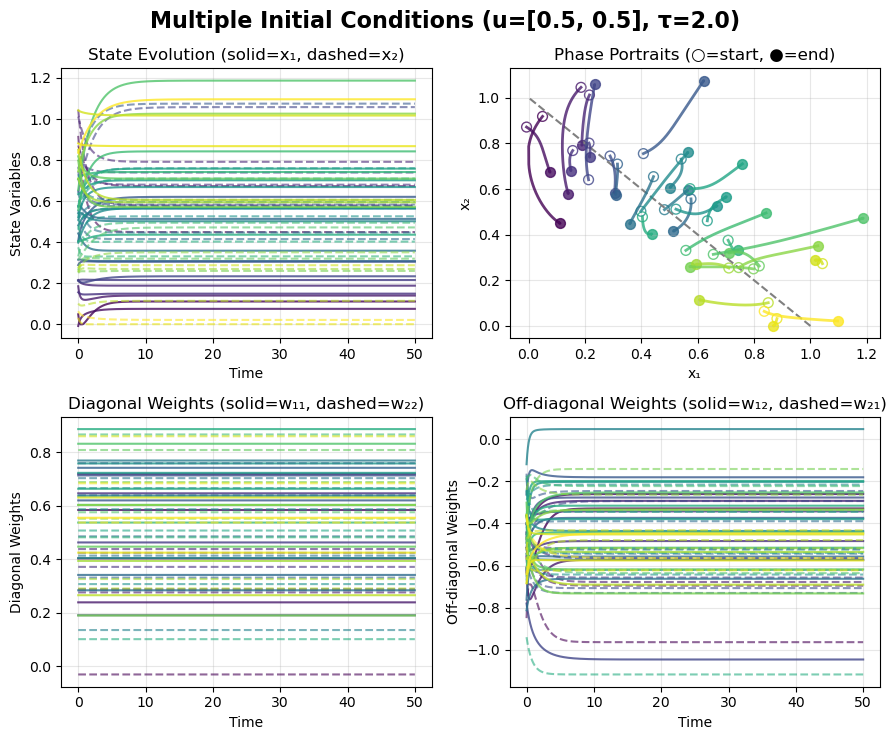

In [148]:
run_simulation(learning_rate=1, homeo_rate=0, seed=11)
None

In [34]:
import sympy as sp

# --- Define symbols ---
x1 = sp.symbols('x1', real=True)        # neural activities at fixed point
tau, c, u, alpha = sp.symbols('tau c u alpha', real=True)       # tau and c from your definitions
x2 = -u/c - x1

# --- Neural-neural block J_xx ---
J_xx = sp.Matrix([[c, c],
                  [c, c]])

# --- Neural-weight block J_xw ---
# order of weights: w11, w12, w21, w22
J_xw = sp.Matrix([[x1, x2, 0, 0],
                  [0, 0, x1, x2]])

# --- Weight-neural block J_wx ---
J_wx = sp.Matrix([
    [0, 0],
    [tau**2 * (x1 - x2) * c, tau**2 * (x1 - x2) * c],
    [tau**2 * (x2 - x1) * c, tau**2 * (x2 - x1) * c],
    [0, 0]
])

# --- Weight-weight block J_ww ---
J_ww = sp.Matrix([
    [-alpha, 0, -alpha, 0],
    [-tau**2 * (x1*x2), -tau**2 * x2**2 - alpha, tau**2 * x1**2, tau**2 * x1*x2 - alpha],
    [tau**2 * (x1*x2) - alpha, tau**2 * x2**2, -alpha - tau**2 * x1**2, -tau**2 * (x1*x2)],
    [0, -alpha, 0, -alpha]
])

# --- Assemble full 6x6 Jacobian ---
J_top = J_xx.row_join(J_xw)
J_bottom = J_wx.row_join(J_ww)
J = J_top.col_join(J_bottom)

print(J)

# --- Compute eigenvalues and eigenvectors ---
eigen_data = J.eigenvects()

# --- Print results ---
for val, mult, vects in eigen_data:
    print(f"Eigenvalue: {val}, multiplicity: {mult}")
    for v in vects:
        print(f"Eigenvector: {v}")
    print("-"*40)

Matrix([[c, c, x1, -x1 - u/c, 0, 0], [c, c, 0, 0, x1, -x1 - u/c], [0, 0, -alpha, 0, -alpha, 0], [c*tau**2*(2*x1 + u/c), c*tau**2*(2*x1 + u/c), -tau**2*x1*(-x1 - u/c), -alpha - tau**2*(-x1 - u/c)**2, tau**2*x1**2, -alpha + tau**2*x1*(-x1 - u/c)], [c*tau**2*(-2*x1 - u/c), c*tau**2*(-2*x1 - u/c), -alpha + tau**2*x1*(-x1 - u/c), tau**2*(-x1 - u/c)**2, -alpha - tau**2*x1**2, -tau**2*x1*(-x1 - u/c)], [0, 0, 0, -alpha, 0, -alpha]])
Eigenvalue: 0, multiplicity: 2
Eigenvector: Matrix([[-1], [1], [0], [0], [0], [0]])
Eigenvector: Matrix([[0], [0], [(-c*x1 - u)/(c*x1)], [-1], [(c*x1 + u)/(c*x1)], [1]])
----------------------------------------
Eigenvalue: -2*alpha, multiplicity: 1
Eigenvector: Matrix([[0], [0], [(c*x1 + u)/(c*x1)], [1], [(c*x1 + u)/(c*x1)], [1]])
----------------------------------------
Eigenvalue: -(-3*(-4*alpha*c**3 + alpha*tau**2*u**2 - c*tau**2*u**2)/c**2 + (2*alpha*c**2 - 2*c**3 + 2*c**2*tau**2*x1**2 + 2*c*tau**2*u*x1 + tau**2*u**2)**2/c**4)/(3*(-27*alpha*tau**2*u**2/c + sqrt

-1.2226480727836329 [-7.36883094e-01 -6.72674987e-01 -3.91655310e-04  4.74940057e-02
 -4.74940057e-02  3.91655310e-04]
-0.12228689456900886 [-0.65921476  0.73486021 -0.00999994  0.1122862  -0.1122862   0.00999994]
-0.020065032647359652 [-0.13524106 -0.38142498  0.45574234 -0.45870615  0.45870615 -0.45574234]
8.95241707378136e-18 [ 0.05981943 -0.05981943  0.64760381 -0.27754449 -0.64760381  0.27754449]
-6.714614044253924e-17 [-0.70539477  0.70539477  0.04519933 -0.01937114 -0.04519933  0.01937114]
-0.020000000000000028 [-4.95174009e-14 -1.54294647e-13  6.49933684e-01 -2.78543007e-01
  6.49933684e-01 -2.78543007e-01]


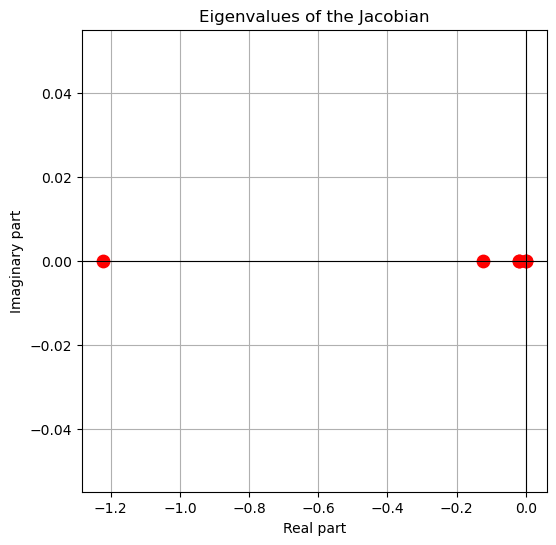

In [37]:
param_values = {
    x1: 0.5,
    tau: 0.3,
    c: -0.6,
    u: 1.0,
    alpha: 0.01,
}

# Substitute numerical values into the Jacobian
J_num = J.subs(param_values)
J_num = np.array(J_num).astype(np.float64)  # convert to numpy array for plotting

# --- Compute eigenvalues numerically ---
eigvals = np.linalg.eigvals(J_num)

res = np.linalg.eig(J_num)
for i in range(len(res.eigenvalues)):
    print(res.eigenvalues[i], res.eigenvectors[:, i])

# --- Plot eigenvalues in the complex plane ---
plt.figure(figsize=(6,6))
plt.scatter(eigvals.real, eigvals.imag, color='red', s=80)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel("Real part")
plt.ylabel("Imaginary part")
plt.title("Eigenvalues of the Jacobian")
plt.grid(True)
plt.show()